# Decision Tree
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn import tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)


---------------------------

## Load Data

In [2]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [3]:
y = spaceship_data["Transported"].astype(int)
X = spaceship_data.drop(columns=["Transported", "GroupId"])

## Train-Test Split

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

פרמטרים ליצירת פולדים בהמשך

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## בדיקת אופטימליות על כל אחד מההייפר פרמטרים בנפרד

שמירת ההייפר פרמטרים הטובים ביותר

In [6]:
best_params = {}
best_score = -1

criterion

In [7]:
for crit in ["gini", "entropy"]:
    dt = DecisionTreeClassifier(criterion=crit, random_state=42) 
    fold_scores = cross_val_score(dt, x_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

    mean_score = fold_scores.mean()
    if mean_score > best_score:
       best_score = mean_score
       best_params = {"criterion": crit}


print("\nBest params so far:", best_params)
print(f"Best CV accuracy: {100 * best_score:.2f}%")
    


Best params so far: {'criterion': 'entropy'}
Best CV accuracy: 74.41%


max_depth

In [8]:
best_score = -1

In [9]:
for depth in range(1, 31):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, criterion = best_params["criterion"]) 
    fold_scores = cross_val_score(dt, x_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

    mean_score = fold_scores.mean()

    if mean_score > best_score:
        best_score = mean_score
        best_params["max_depth"] = depth 

print("\nBest params so far:", best_params)
print(f"Best CV accuracy: {100 * best_score:.2f}%")


Best params so far: {'criterion': 'entropy', 'max_depth': 7}
Best CV accuracy: 77.30%


min_samples_leaf

In [10]:
best_score = -1

In [11]:
for leaf in range(1, 101):
    dt = DecisionTreeClassifier(random_state=42, 
                                criterion = best_params["criterion"],
                                max_depth=best_params["max_depth"],
                                min_samples_leaf=leaf)
    fold_scores = cross_val_score(dt, x_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1
    )

    mean_score = fold_scores.mean()

    if mean_score > best_score:
        best_score = mean_score
        best_params["min_samples_leaf"] = leaf

print("\nBest params so far:", best_params)
print(f"Best CV accuracy: {100 * best_score:.2f}%")


Best params so far: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 87}
Best CV accuracy: 77.99%


min_samples_split

In [12]:
best_score = -1

In [13]:
for split in range(2, 101):
    if split <= best_params["min_samples_leaf"]:
        continue

    dt = DecisionTreeClassifier(
        random_state=42,
        criterion=best_params["criterion"],
        max_depth=best_params["max_depth"],
        min_samples_leaf=best_params["min_samples_leaf"],
        min_samples_split=split
    )

    fold_scores = cross_val_score(
        dt, x_train, y_train,
        cv=cv, scoring="accuracy", n_jobs=-1
    )

    mean_score = fold_scores.mean()

    if mean_score > best_score:
        best_score = mean_score
        best_params["min_samples_split"] = split

print("\nBest params so far:", best_params)
print(f"Best CV accuracy: {100 * best_score:.2f}%")



Best params so far: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 87, 'min_samples_split': 88}
Best CV accuracy: 77.99%


max_leaf_nodes

In [14]:
best_score = -1


In [15]:
for nodes in range(10, 301, 1):

    dt = DecisionTreeClassifier(
        random_state=42,
        criterion=best_params["criterion"],
        max_depth=best_params["max_depth"],
        min_samples_leaf=best_params["min_samples_leaf"],
        min_samples_split=best_params["min_samples_split"],
        max_leaf_nodes=nodes
    )

    fold_scores = cross_val_score(
        dt,
        x_train, y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    mean_score = fold_scores.mean()

    if mean_score > best_score:
        best_score = mean_score
        best_params["max_leaf_nodes"] = nodes

print("\nBest params so far:", best_params)
print(f"Best CV accuracy: {100 * best_score:.2f}%")


Best params so far: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 87, 'min_samples_split': 88, 'max_leaf_nodes': 38}
Best CV accuracy: 78.11%


## בניית המודל הסופי

In [16]:
final_dt = DecisionTreeClassifier(random_state=42, **best_params)

In [17]:
final_dt.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=7, max_leaf_nodes=38,
                       min_samples_leaf=87, min_samples_split=88,
                       random_state=42)

In [18]:
y_pred = final_dt.predict(x_test)

{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 87, 'min_samples_split': 88, 'max_leaf_nodes': 38}


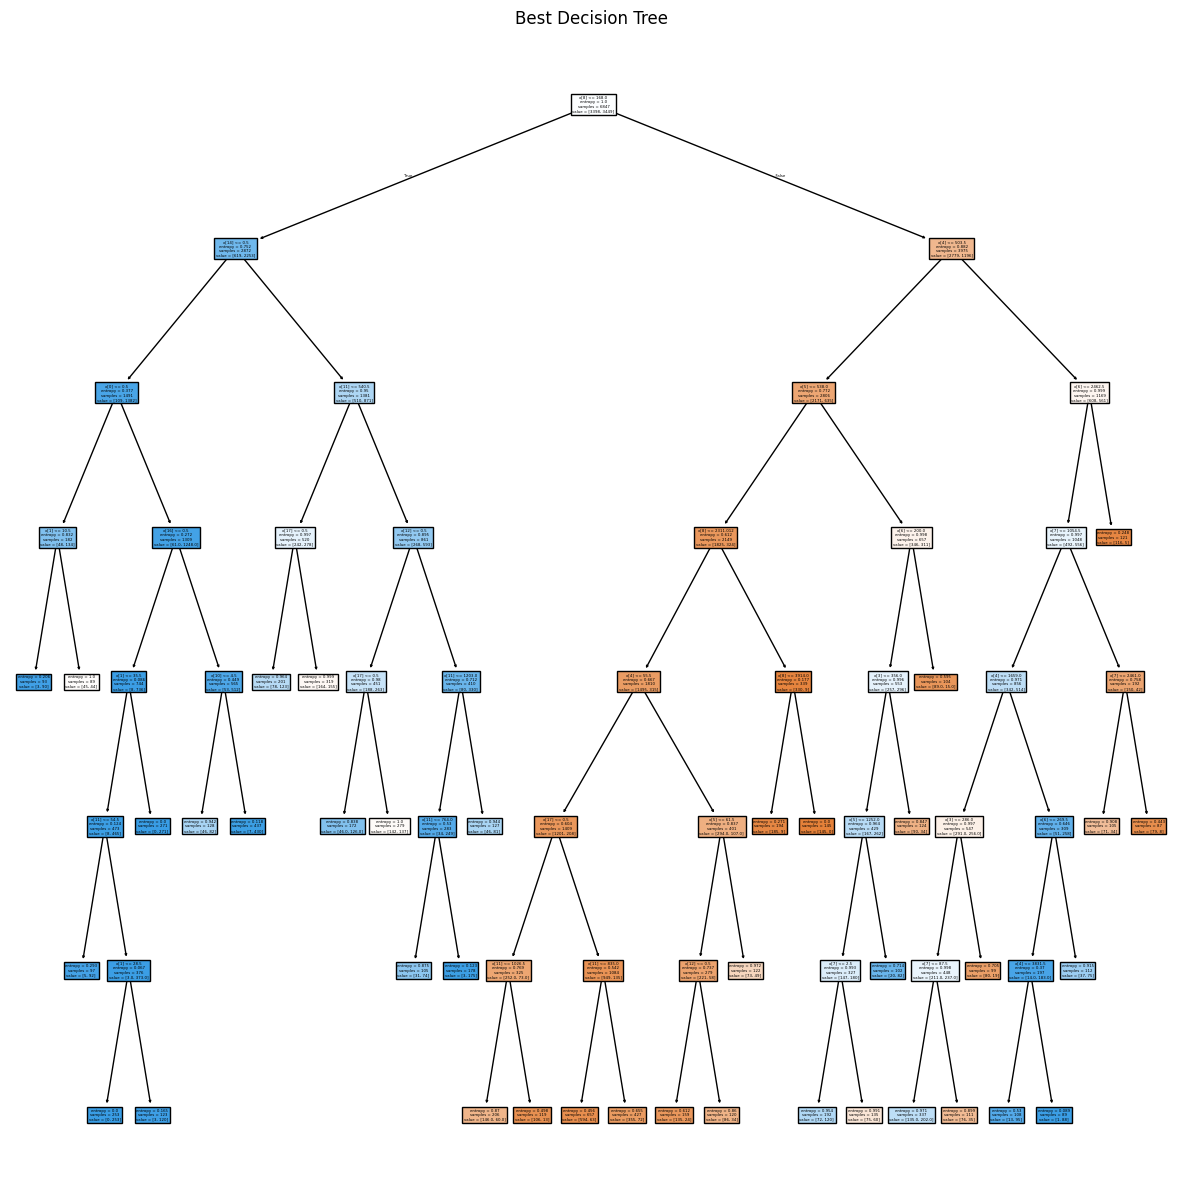

In [19]:
print(best_params)
plt.figure(figsize=(15, 15))
ax = plt.axes()
tree.plot_tree(final_dt, filled=True, ax=ax)
plt.title(f'Best Decision Tree')
plt.show()
    

In [20]:
final_params_df = pd.DataFrame(
    list(best_params.items()),
    columns=["Parameter", "Value"]
)

# תצוגה יפה
display(final_params_df)

,Parameter,Value
0,criterion,entropy
1,max_depth,7
2,min_samples_leaf,87
3,min_samples_split,88
4,max_leaf_nodes,38


## Results

In [21]:
y_pred_test  = final_dt.predict(x_test)
y_pred_train  = final_dt.predict(x_train)

In [ ]:
train_acc = accuracy_score(y_train, y_pred_train)

In [23]:
print("="*40)
print("BEST Decision Tree — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc*100:.2f}%")
print("="*40)

BEST Decision Tree — TRAIN SET PERFORMANCE
Accuracy : 79.32%


#### Confusion Matrix - Train

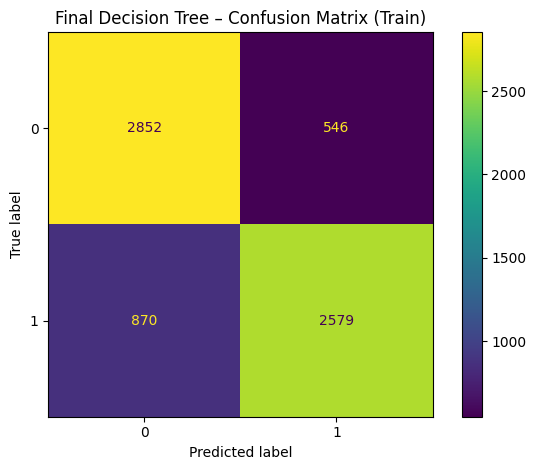

In [24]:
cm_train = confusion_matrix(y_train, y_pred_train)
ConfusionMatrixDisplay(confusion_matrix=cm_train).plot(values_format="d")
plt.title("Final Decision Tree – Confusion Matrix (Train)")
plt.tight_layout()
plt.show()

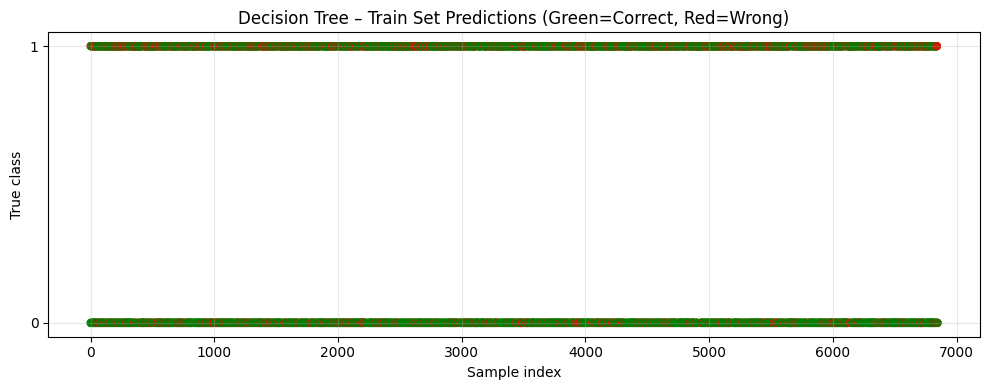

Decision Tree Train Accuracy: 79.32%
Errors: 1416 / 6847


In [25]:
correct = (y_pred_train == y_train)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_train)), y_train, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("Decision Tree – Train Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Decision Tree Train Accuracy: {100*train_acc:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

#### חישוב Precision, Recall, F1 מתוך ה-CM

In [26]:
TN_train, FP_train, FN_train, TP_train = cm_train.ravel()

precision_train = TP_train / (TP_train + FP_train)
recall_train    = TP_train / (TP_train + FN_train)
f1_train        = 2 * (precision_train * recall_train) / (precision_train + recall_train)

print("="*40)
print("BEST Decision Tree — TRAIN SET PERFORMANCE")
print(f"Precision: {precision_train:.3f}")
print(f"Recall:    {recall_train:.3f}")
print(f"F1 Score:  {f1_train:.3f}")
print("="*40)

BEST Decision Tree — TRAIN SET PERFORMANCE
Precision: 0.825
Recall:    0.748
F1 Score:  0.785
